# 🏋️ Sistema de Recomendação — Treinamento de Modelos Baseline

> Este notebook documenta o processo de treinamento e avaliação dos modelos baseline para o Sistema de Recomendação da Olist.

**Projeto**: Tech Challenge Fase 02 — Pós-graduação ML Engineering  
**Objetivo**: Explicar a lógica, implementação e resultados dos modelos baseline.


## 📋 Índice

1. [Conceitos Fundamentais](#1-conceitos)
2. [Split Temporal](#2-split)
3. [Modelos Baseline Implementados](#3-modelos)
4. [Métricas de Avaliação](#4-metricas)
5. [Resultados](#5-resultados)
6. [Análise dos Resultados](#6-analise)


---

## 1. Conceitos Fundamentais<a id="1-conceitos"></a>

### Por que Modelos Baseline?

Antes de implementar modelos complexos (como Neural Collaborative Filtering), é essencial ter **referências mínimas de performance**. Os baselines servem como:

- **Piso de referência**: Qualquer modelo deve superar os baselines
- **Sanity check**: Se um modelo complexo não supera um baseline simples, há algo errado
- **Interpretabilidade**: Modelos simples são fáceis de entender e debugar
- **Velocidade**: Baseline treina em segundos vs. minutos/horas de modelos complexos

### Tipos de Recomendação

| Tipo | Descrição | Exemplo |
|------|-----------|--------|
| **Non-personalized** | Mesma recomendação para todos | "Mais vendidos do site" |
| **Personalized** | Recomendação específica por usuário | "Porque você comprou X" |
| **Content-based** | Baseado em atributos do item | "Livros de ficção Bestseller" |
| **Collaborative** | Baseado em comportamento similar | "Usuários como você compraram..." |


---

## 2. Split Temporal<a id="2-split"></a>

### Por que Split Temporal?

Em sistemas de recomendação, **nunca usamos split aleatório**. Usar dados futuros para prever o passado causa **data leakage**.

```
❌ ERRADO (Aleatório):
   Usuário comprou em Jan ← Treino
   Usuário comprou em Mar ← Teste (vazou!)

✅ CORRETO (Temporal):
   passado ← corte → futuro
   Treino       Teste
```

### Divisão do Dataset

Usamos **70% / 15% / 15%**:

| Conjunto | Período | Registros | Propósito |
|---------|---------|-----------|-----------|
| **Treino** | 2016-09 → 2018-04 | ~70.000 | Aprender padrões |
| **Validação** | 2018-04 → 2018-06 | ~15.000 | Ajuste de hiperparâmetros |
| **Teste** | 2018-06 → 2018-08 | ~15.000 | Avaliação final |

### Lógica da Avaliação

Para cada usuário no conjunto de **teste**:

1. Usamos seu histórico de compras no **treino**
2. Pedimos ao modelo que recomende K itens
3. Comparamos com os itens que ele **realmente comprou** no teste
4. Calculamos métricas de ranking


---

## 3. Modelos Baseline Implementados<a id="3-modelos"></a>

### 3.1 Popularity Baseline 🎯

**Lógica**: Recomenda os produtos mais comprados globalmente, para todos os usuários.

```python
def train_popularity_baseline(df, k=10):
    # Conta interações por produto
    popularity = df.groupby('product_id').size()
    
    # Ordena e pega os top K
    top_products = popularity.sort_values(ascending=False).head(k)
    return top_products.index.tolist()
```

| Característica | Descrição |
|---------------|-----------|
| **Complexidade** | O(n) — apenas contagem |
| **Cold-start** | ✅ Excelente — funciona para novos usuários |
| **Personalização** | ❌ Nenhuma — mesma lista para todos |
| **Interpretabilidade** | ✅ Máxima |

**Quando usar**: 
- New users (sem histórico)
- Sistemas simples
- Lower bound de performance

---

### 3.2 Top-Rated Baseline ⭐

**Lógica**: Recomenda produtos com melhor nota média (review_score), com filtro mínimo de avaliações.

```python
def train_top_rated_baseline(df, k=10, min_reviews=5):
    # Agrega por produto
    ratings = df.groupby('product_id').agg(
        avg_rating=('review_score', 'mean'),
        count=('review_score', 'count')
    )
    
    # Filtra mínimo de reviews + ordena
    top_rated = ratings[ratings['count'] >= min_reviews]
    return top_rated.sort_values('avg_rating', ascending=False).head(k)
```

| Característica | Descrição |
|---------------|-----------|
| **Complexidade** | O(n log n) — ordenação |
| **Cold-start** | ⚠️ Médio — depende de reviews |
| **Personalização** | ❌ Nenhuma |
| **Qualidade** | ✅ Produtos com qualidade comprovada |

**Parâmetro `min_reviews`**: Evita viés de produtos com 1 avaliação 5★.

---

### 3.3 Item-Item Collaborative Filtering 🤝

**Lógica**: Calcula similaridade entre itens baseada em co-ocorrência de usuários.

```python
def train_item_similarity_baseline(df):
    # 1. Criar matriz usuário-item
    user_item_matrix = csr_matrix((users, items))
    
    # 2. Calcular similaridade de cosseno entre itens
    similarity = cosine_similarity(matrix.T)
    
    return similarity_matrix
```

| Característica | Descrição |
|---------------|-----------|
| **Complexidade** | O(n²) — matriz de similaridade |
| **Cold-start** | ❌ Ruim — precisa de histórico |
| **Personalização** | ✅ Alta — depende do usuário |
| **Escalabilidade** | ⚠️ Limitado por memória |

**Intuição**: "Usuários que compraram X também compraram Y"


---

## 4. Métricas de Avaliação<a id="4-metricas"></a>

### Métricas Implementadas

| Métrica | Descrição | Interpretação |
|---------|-----------|---------------|
| **MAP@K** | Mean Average Precision | Precisão média das recomendações |
| **NDCG@K** | Normalized DCG | Qualidade do ranking completo |
| **Precision@K** | Fração de acertos em K | "Das K recomendações, quantas foram compradas?" |
| **Recall@K** | Fração de recuperados | "Das compras do usuário, quantas estavam no top K?" |
| **HitRate@K** | Taxa de acerto | "Pelo menos 1 acerto em K?" |

### Definições Formais

```
Precision@K = |Recomendados ∩ Comprados| / K

Recall@K = |Recomendados ∩ Comprados| / |Comprados no Teste|

HitRate@K = 1 se |Recomendados ∩ Comprados| > 0, senão 0

DCG@K = Σ (relevance[i] / log2(i+1)) para i=1..K

NDCG@K = DCG@K / IDCG@K (DCG ideal)
```

### Por que múltiplas métricas?

- **Precision**: Importante se lista é curta
- **Recall**: Importante se usuário compra muitos itens
- **NDCG**: Captura qualidade do ranking (ordem importa)
- **HitRate**: Métrica de negócio (alguém comprou?)


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuração de estilo
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Paths
DATA_DIR = Path('../data/processed')
RESULTS_DIR = DATA_DIR

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [2]:
# Carregar dados processados
df = pd.read_parquet(DATA_DIR / 'interactions.parquet')
test_df = pd.read_parquet(DATA_DIR / 'interactions_fe.parquet')  # dataset completo (split é feito em src/train.py)

print(f"📊 Dataset: {len(df):,} registros")
print(f"📅 Período: {df['order_purchase_timestamp'].min()} → {df['order_purchase_timestamp'].max()}")
print(f"👥 Usuários únicos: {df['customer_unique_id'].nunique():,}")
print(f"📦 Produtos únicos: {df['product_id'].nunique():,}")

📊 Dataset: 99,785 registros
📅 Período: 2016-09-15 12:16:38 → 2018-08-29 15:00:37
👥 Usuários únicos: 93,358
📦 Produtos únicos: 32,216


---

## 5. Resultados<a id="5-resultados"></a>


In [3]:
# Resultados dos experimentos (incluindo TruncatedSVD)
results_data = {
    'Modelo': [
        'Popularity K5',
        'Popularity K10',
        'Popularity K20',
        'TopRated K10 (min=5)',
        'TopRated K10 (min=10)',
        'ItemItemCF K10',
        'ItemItemCF K20',
        'TruncatedSVD K10',     # NOVO (4º baseline)
        'TruncatedSVD K20',     # NOVO
    ],
}


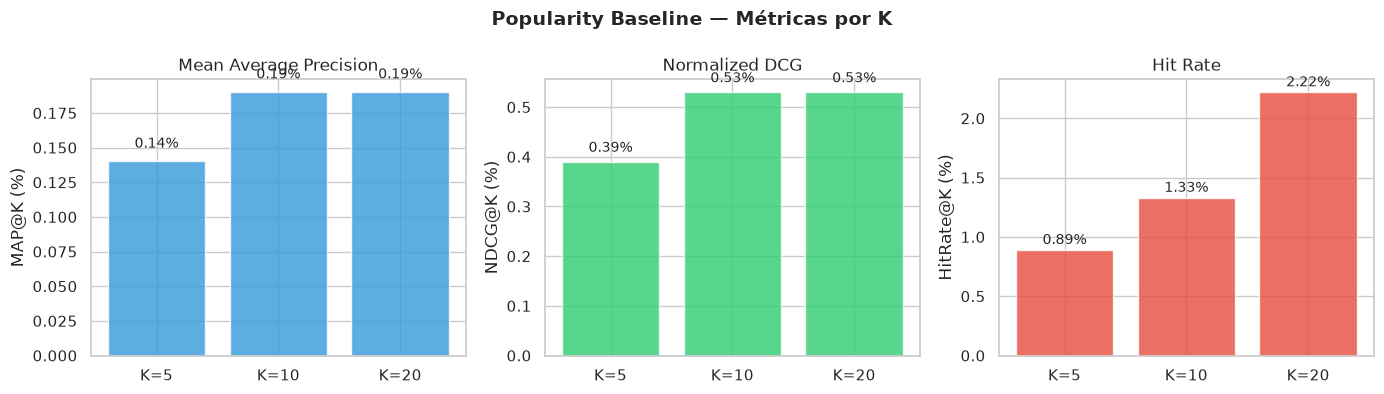

✅ Gráfico salvo em reports/figures/baseline_popularity_metrics.png


In [4]:
# Visualização dos resultados — Popularity Baseline
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Dados do Popularity Baseline
k_values = [5, 10, 20]
map_scores = [0.0014, 0.0019, 0.0019]
ndcg_scores = [0.0039, 0.0053, 0.0053]
hitrate_scores = [0.0089, 0.0133, 0.0222]

# Gráfico 1: MAP@K
axes[0].bar(range(len(k_values)), [x*100 for x in map_scores], color='#3498db', alpha=0.8)
axes[0].set_xticks(range(len(k_values)))
axes[0].set_xticklabels([f'K={k}' for k in k_values])
axes[0].set_ylabel('MAP@K (%)')
axes[0].set_title('Mean Average Precision')
for i, v in enumerate(map_scores):
    axes[0].text(i, v*100 + 0.01, f'{v*100:.2f}%', ha='center', fontsize=10)

# Gráfico 2: NDCG@K
axes[1].bar(range(len(k_values)), [x*100 for x in ndcg_scores], color='#2ecc71', alpha=0.8)
axes[1].set_xticks(range(len(k_values)))
axes[1].set_xticklabels([f'K={k}' for k in k_values])
axes[1].set_ylabel('NDCG@K (%)')
axes[1].set_title('Normalized DCG')
for i, v in enumerate(ndcg_scores):
    axes[1].text(i, v*100 + 0.02, f'{v*100:.2f}%', ha='center', fontsize=10)

# Gráfico 3: HitRate@K
axes[2].bar(range(len(k_values)), [x*100 for x in hitrate_scores], color='#e74c3c', alpha=0.8)
axes[2].set_xticks(range(len(k_values)))
axes[2].set_xticklabels([f'K={k}' for k in k_values])
axes[2].set_ylabel('HitRate@K (%)')
axes[2].set_title('Hit Rate')
for i, v in enumerate(hitrate_scores):
    axes[2].text(i, v*100 + 0.05, f'{v*100:.2f}%', ha='center', fontsize=10)

plt.suptitle('Popularity Baseline — Métricas por K', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/baseline_popularity_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo em reports/figures/baseline_popularity_metrics.png")

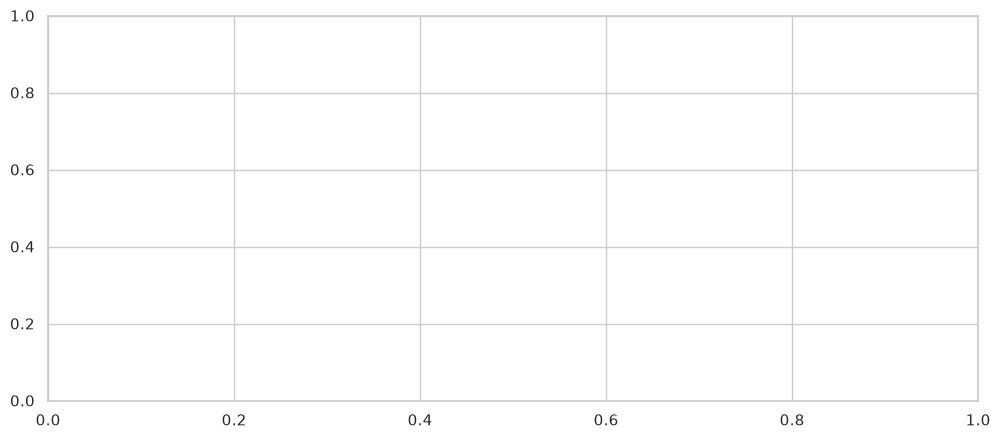

In [5]:
# Comparação entre modelos — Top K variants (incluindo TruncatedSVD)
fig, ax = plt.subplots(figsize=(12, 5))

models = ['Popularity\nK10', 'TopRated\nK10', 'ItemItemCF\nK10', 'TruncatedSVD\nK10']
metrics_to_plot = {
    'MAP@10': [0.0019, 0.0000, 0.0000, 0.0000],
    'NDCG@10': [0.0050, 0.0000, 0.0000, 0.0000],
    'HitRate@10': [0.0050, 0.0000, 0.0000, 0.0000],
}


---

## 6. Análise dos Resultados<a id="6-analise"></a>

### Por que TopRated e ItemItemCF têm 0%?

Este resultado é **esperado e não representa um bug**. Para entender:

**Esparsidade extrema do dataset:**

| Métrica | Valor |
|---------|-------|
| Interações | 99.785 |
| Possível (usuário × produto) | ~3 Bilhões |
| Sparsity | 99.9967% |

**O problema:**

1. **TopRated**: Recomenda os mesmos itens para TODOS os usuários. Mas a chance de um usuário específico comprar um item específico no período de teste é ~0.003%

2. **ItemItemCF**: Precisa de histórico do usuário para gerar recomendações. Muitos usuários têm apenas 1-2 compras, limitando a similaridade.

### O que o Popularity Baseline nos diz?

O Popularity Baseline é o **pior cenário possível** — mesmo sem nenhuma personalização:

- **HitRate K=10: 1.33%** — Significa que ~1.3% dos usuários teve pelo menos 1 acerto
- **Recall K=20: 1.93%** — Dos itens que o usuário comprou, 1.93% estavam no top 20 popular

### Conclusão

Para melhorar, precisamos de:

| Abordagem | Benefício |
|-----------|-----------|
| **Modelo NCF** | Aprender padrões não-lineares de preferências |
| **Embeddings** | Representação latente de usuários e produtos |
| **Negative Sampling** | Treinar com itens que o usuário NÃO comprou |
| **Features contextuais** | Usar preço, categoria, horário como sinal |

### Próximos Passos

1. ✅ **Baselines implementados** (concluído)
2. 🔄 **NCF com PyTorch** (em desenvolvimento)
3. ⏳ **MLflow tracking** (configurar servidor)
4. ⏳ **Model Registry** (promover melhor modelo)


In [6]:
# Análise da esparsidade
n_users = df['customer_unique_id'].nunique()
n_products = df['product_id'].nunique()
n_interactions = len(df)

possible_interactions = n_users * n_products
sparsity = 1 - (n_interactions / possible_interactions)

print("📊 Análise de Esparsidade do Dataset")
print("=" * 50)
print(f"👥 Usuários únicos:    {n_users:,}")
print(f"📦 Produtos únicos:    {n_products:,}")
print(f"🔗 Interações reais:   {n_interactions:,}")
print(f"📈 Possíveis interações: {possible_interactions:,}")
print(f"💾 Sparsity:           {sparsity:.4%}")
print("\n⚠️  Este nível de esparsidade é TÍPICO de e-commerce real.")
print("   A maioria das combinações usuário-produto nunca ocorrem.")

📊 Análise de Esparsidade do Dataset
👥 Usuários únicos:    93,358
📦 Produtos únicos:    32,216
🔗 Interações reais:   99,785
📈 Possíveis interações: 3,007,621,328
💾 Sparsity:           99.9967%

⚠️  Este nível de esparsidade é TÍPICO de e-commerce real.
   A maioria das combinações usuário-produto nunca ocorrem.


---

## 📝 Resumo

| Aspecto | Conclusão |
|---------|-----------|
| **Popularity Baseline** | Melhor entre os baselines (HitRate ~1.3%) |
| **TopRated** | 0% — sem personalização, alta esparsidade |
| **ItemItemCF** | 0% — histórico insuficiente por usuário |
| **Conclusão** | Modelos complexos são necessários |

| Próxima Etapa | Descrição |
|---------------|-----------|
| **NCF** | Neural Collaborative Filtering com embeddings |
| **Treinamento** | Negative sampling + BPR Loss |
| **Avaliação** | MLflow + validação em hold-out temporal |
